# Numerical mixing

This notebook plots numerical mixing diagnostics for all experiments.

In [50]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar-PPMH3
│        - hycom-default-PPMH3
│        - hycom-dz3-PPMH3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


In [25]:
ds = NCDataset(catalogue["zstar-PPMH3"]["static"])
wet = ds["wet"][:, :]
replace!(wet, 0 => NaN)
close(ds)

# zstar
crs_zstar = get_geo_coords(catalogue["zstar-PPMH3"]["static"], catalogue["zstar-PPMH3"]["vc"])
ds = NCDataset(catalogue[hy_key]["monthlyz"])
zl_zstar = -ds["z_l"][:]
close(ds)

∫nm_zstar = vertical_sum(catalogue["zstar-PPMH3"]["monthlyz"])
∫nm_zstar = dropdims(∫nm_zstar, dims = (3, 4))
∫nm_zstar .*= wet
zm_var_diss_zstar = zonal_variance_dissipation(catalogue["zstar-PPMH3"]["monthlyz"])
zm_var_diss_zstar = dropdims(zm_var_diss_zstar, dims = (1, 4))

# hycom default
hy_key = "hycom-default-PPMH3"
crs_hycom = get_geo_coords(catalogue[hy_key]["static"], catalogue[hy_key]["vc"])
ds = NCDataset(catalogue[hy_key]["monthlyz"])
zl_hycom_d = -ds["z_l"][:]
close(ds)

∫nm_hycom_d = vertical_sum(catalogue[hy_key]["monthlyz"])
∫nm_hycom_d = dropdims(∫nm_hycom_d, dims = (3, 4))
∫nm_hycom_d .*= wet
zm_var_diss_hycom_d = zonal_variance_dissipation(catalogue[hy_key]["monthlyz"])
zm_var_diss_hycom_d = dropdims(zm_var_diss_hycom_d, dims = (1, 4))

# hycom dz = 3
hy_key = "hycom-dz3-PPMH3"
crs_hycom_dz3 = get_geo_coords(catalogue[hy_key]["static"], catalogue[hy_key]["vc"])
ds = NCDataset(catalogue[hy_key]["monthlyz"])
zl_hycom_dz3 = -ds["z_l"][:]
close(ds)

∫nm_hycom_dz3 = vertical_sum(catalogue[hy_key]["monthlyz"])
∫nm_hycom_dz3 = dropdims(∫nm_hycom_dz3, dims = (3, 4))
∫nm_hycom_dz3 .*= wet
zm_var_diss_hycom_dz3 = zonal_variance_dissipation(catalogue[hy_key]["monthlyz"])
zm_var_diss_hycom_dz3 = dropdims(zm_var_diss_hycom_dz3, dims = (1, 4))

nothing

## Variance dissipation

###  Depth integrated

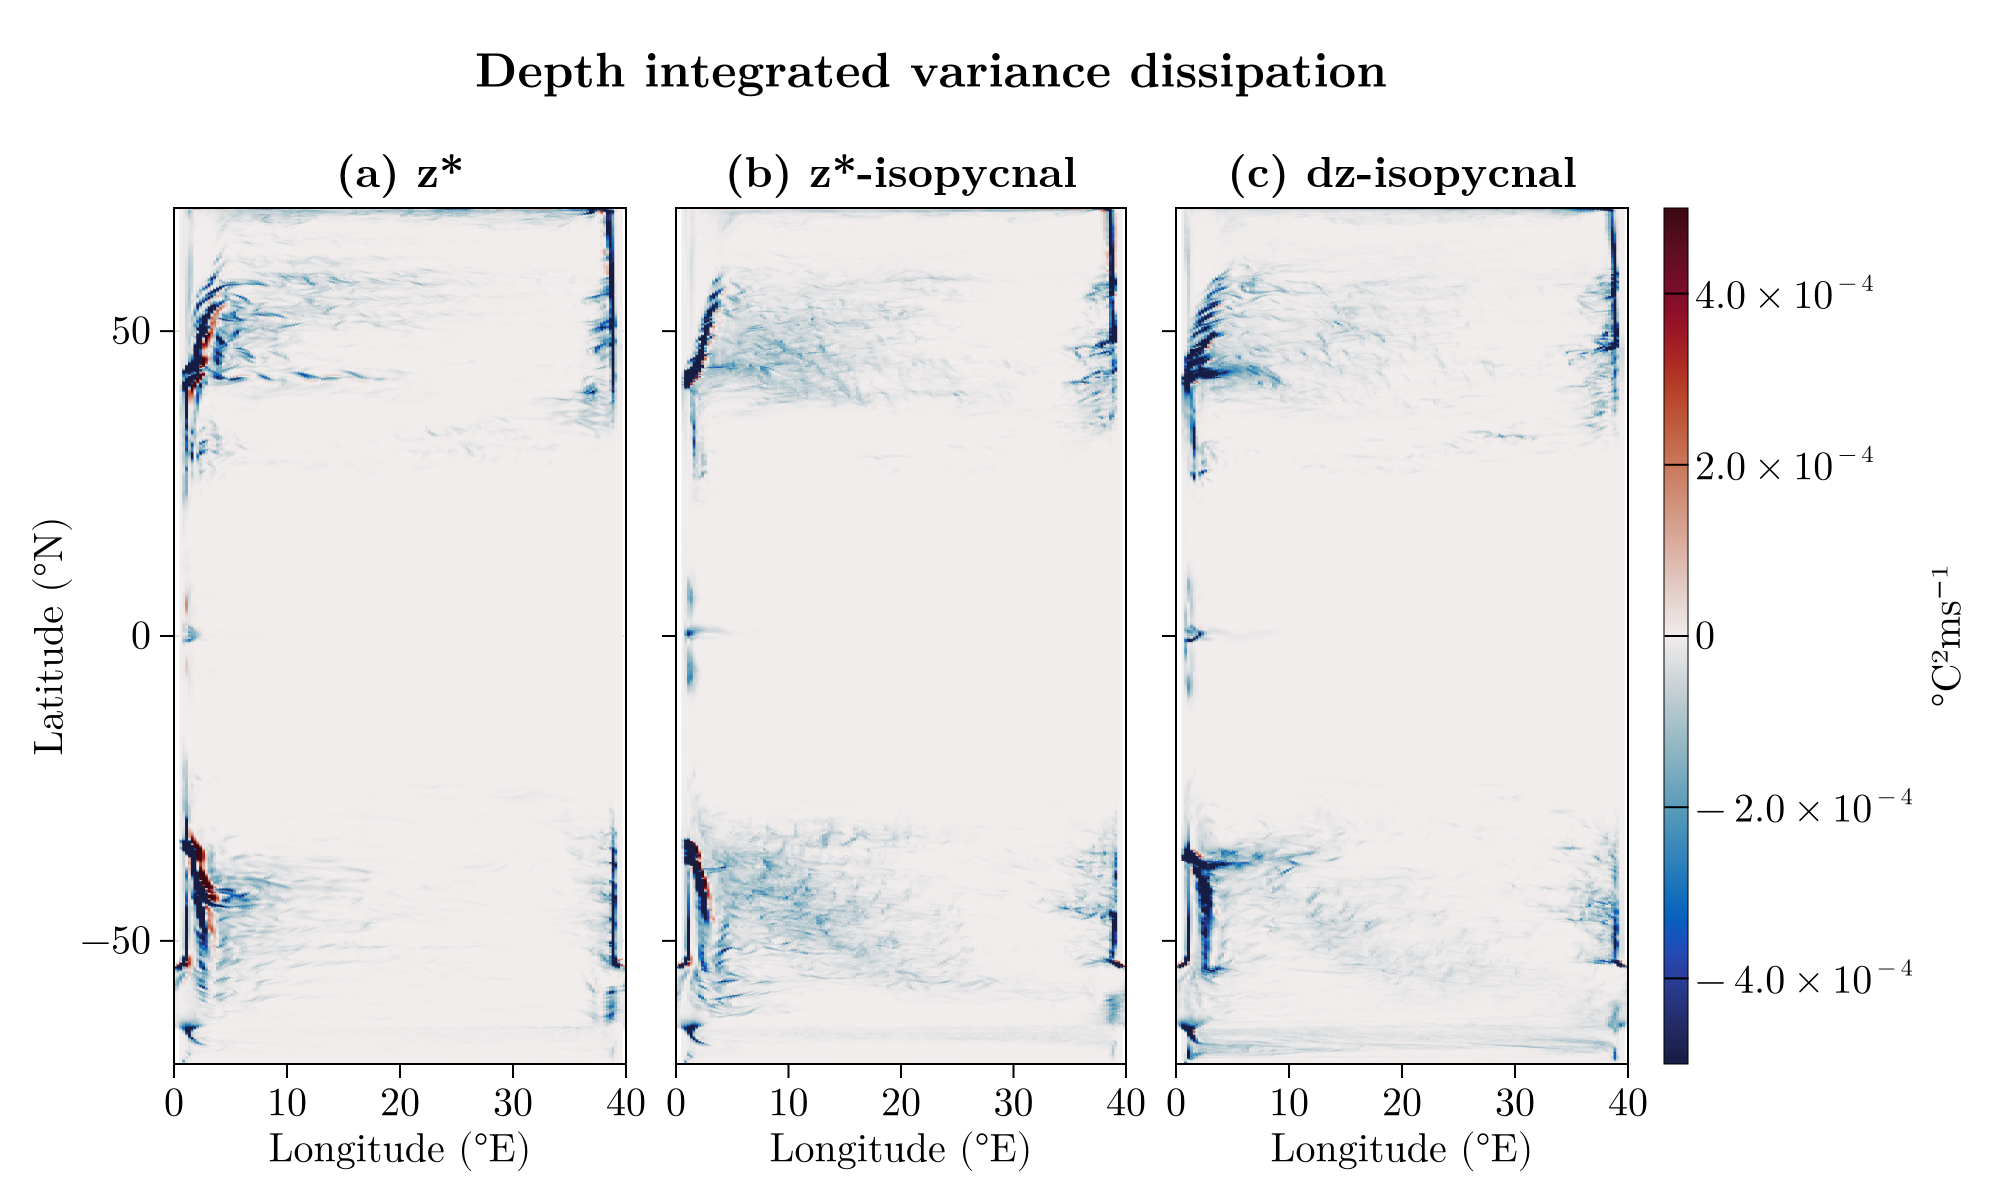

In [26]:
fig = Figure(size = (1000, 600))

colorrange = (-5e-4, 5e-4)
colormap = :balance
ax_zstar = Axis(fig[1, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "(a) z*")
hm = heatmap!(ax_zstar, crs_zstar.lonh, crs_zstar.lath, ∫nm_zstar; colorrange, colormap)

ax_hycomd = Axis(fig[1, 2], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "(b) z*-isopycnal")
hideydecorations!(ax_hycomd, ticks = false)
hm = heatmap!(ax_hycomd, crs_hycom.lonh, crs_hycom.lath, ∫nm_hycom_d; colorrange, colormap)

ax_hycomdz3 = Axis(fig[1, 3], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "(c) dz-isopycnal")
hideydecorations!(ax_hycomdz3, ticks = false)
hm = heatmap!(ax_hycomdz3, crs_hycom.lonh, crs_hycom.lath, ∫nm_hycom_dz3; colorrange, colormap)

linkyaxes!(ax_zstar, ax_hycomd)
linkyaxes!(ax_zstar, ax_hycomdz3)

Colorbar(fig[1, 4], hm, label = "°C²ms⁻¹", tickformat = latex_format)

Label(fig[0, :], "Depth integrated variance dissipation", fontsize = 24, font = :bold)

fig

In [27]:
save("depth_int_variance_dissipation.png", fig)

### Zonal mean

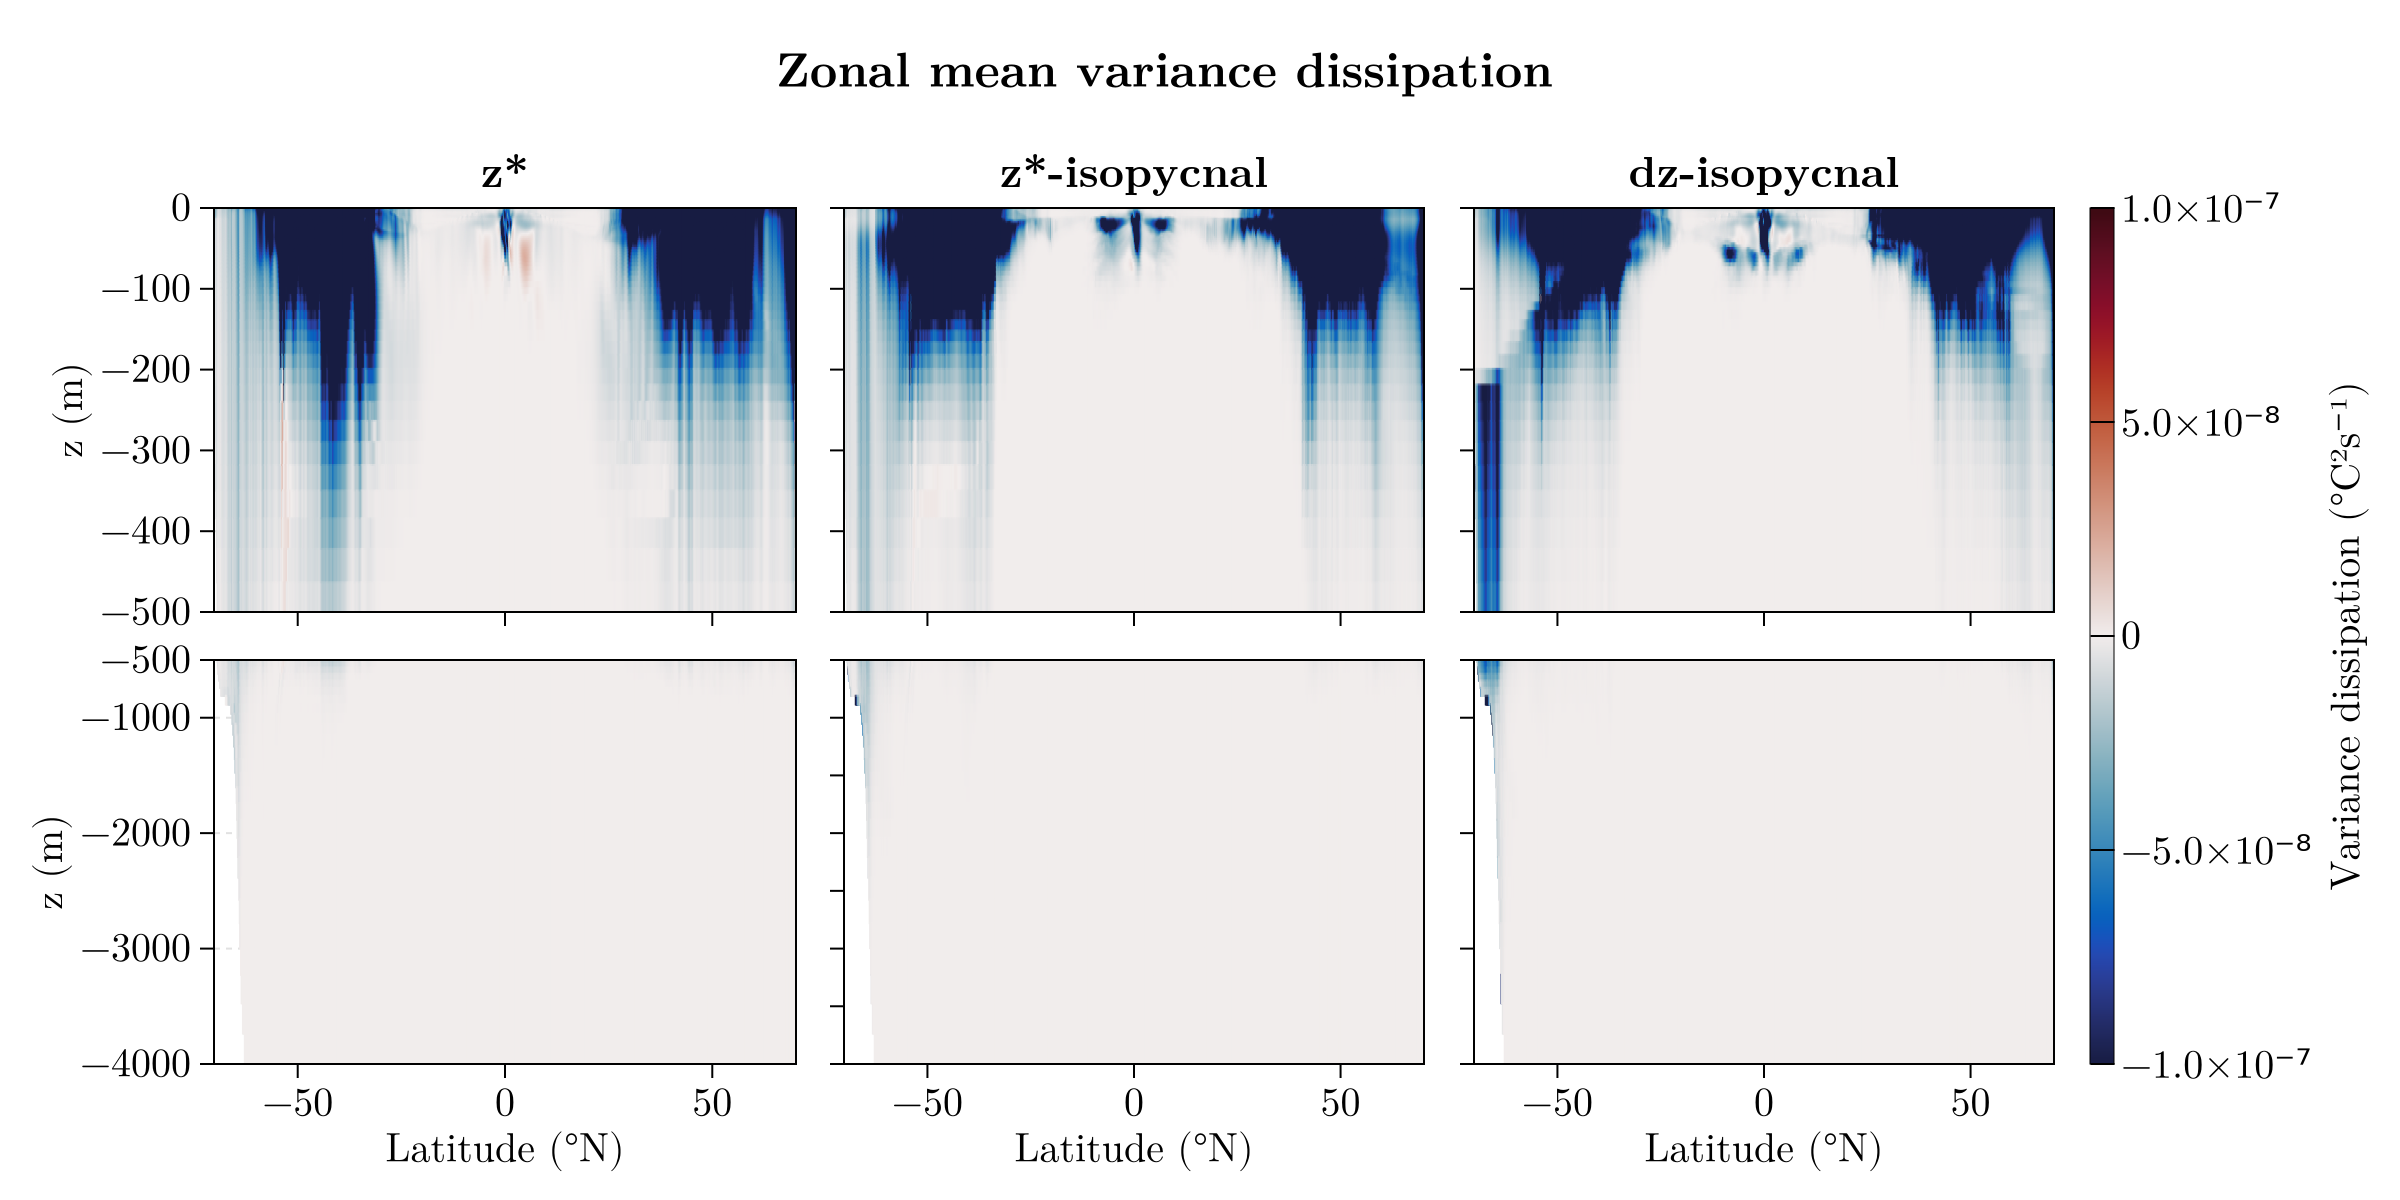

In [28]:
fig = Figure(size = (1200, 600))

colormap = :balance
colorrange = (-1e-7, 1e-7)
top = 1:50
bot = top[end]+1:75

# hycom default top
axtop_hd = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "z*-isopycnal")
hidexdecorations!(axtop_hd, ticks = false)
hideydecorations!(axtop_hd, ticks = false)
hm = heatmap!(axtop_hd, crs_hycom.lath, zl_hycom_d, zm_var_diss_hycom_d; colorrange, colormap)
ylims!(axtop_hd, -500, 0)
# hycom default top
axbot_hd = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot_hd, crs_hycom.lath, zl_hycom_d, zm_var_diss_hycom_d; colorrange, colormap)
hideydecorations!(axbot_hd, ticks = false)
ylims!(axbot_hd, -4000, -500)
axbot.yticks = [-4000, -3000, -2000, -1000, -500]

axtop = Axis(fig[1, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "dz-isopycnal")
hideydecorations!(axtop, ticks = false)
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, crs_hycom.lath, zl_hycom_dz3, zm_var_diss_hycom_dz3; colorrange, colormap)
ylims!(axtop, -500, 0)
axbot = Axis(fig[2, 3], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, crs_hycom.lath, zl_hycom_dz3, zm_var_diss_hycom_dz3; colorrange, colormap)
hideydecorations!(axbot, ticks = false)
ylims!(axbot, -4000, -500)
axbot.yticks = [-4000, -3000, -2000, -1000, -500]

# zstar top, plotted last for ylims
axtop_zs = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "z*")
hm = heatmap!(axtop_zs, crs_zstar.lath, zl_zstar, zm_var_diss_zstar; colorrange, colormap)
ylims!(axtop_zs, -500, 0)
hidexdecorations!(axtop_zs, ticks = false)
# zstar bottom
axbot_zs = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot_zs, crs_zstar.lath, zl_zstar, zm_var_diss_zstar; colorrange, colormap)
ylims!(axbot_zs, -4000, -500)
axbot_zs.yticks = [-4000, -3000, -2000, -1000, -500]

# linkyaxes!(axtop_zs, axtop_hd, axtop)
# linkyaxes!(axbot_zs, axbot_hd, axbot)

Colorbar(fig[:, 4], hm, label = "Variance dissipation (°C²s⁻¹)")

Label(fig[0, :], "Zonal mean variance dissipation", fontsize = 24, font = :bold)

fig

In [29]:
save("zm_variance_dissipation.png", fig)

## Numerical diffusivity, variance production divided by norm of gradient squared 

In [51]:
nm_zstar_diff = zonal_numerical_mixing_diffusivity(catalogue["zstar-PPMH3"]["monthly"], catalogue["zstar-PPMH3"]["static"])
nm_zstar_diff = abs.(nm_zstar_diff)
replace!(nm_zstar_diff, 0 => eps())
# nm_zstar_diff = log10.(abs.(nm_zstar_diff))
# replace!(nm_zstar_diff, -Inf => 0)

hy_key = "hycom-default-PPMH3"
nm_hycom_diff = zonal_numerical_mixing_diffusivity(catalogue[hy_key]["monthly"], catalogue[hy_key]["static"])
nm_hycom_diff = abs.(nm_hycom_diff)
replace!(nm_hycom_diff, 0 => eps())
# nm_hycom_diff = log10.(abs.(nm_hycom_diff))
# replace!(nm_hycom_diff, -Inf => 0)

nothing

# Suggested to plot this on a log scale. To do so will have to take absolute value as there are some negative values.

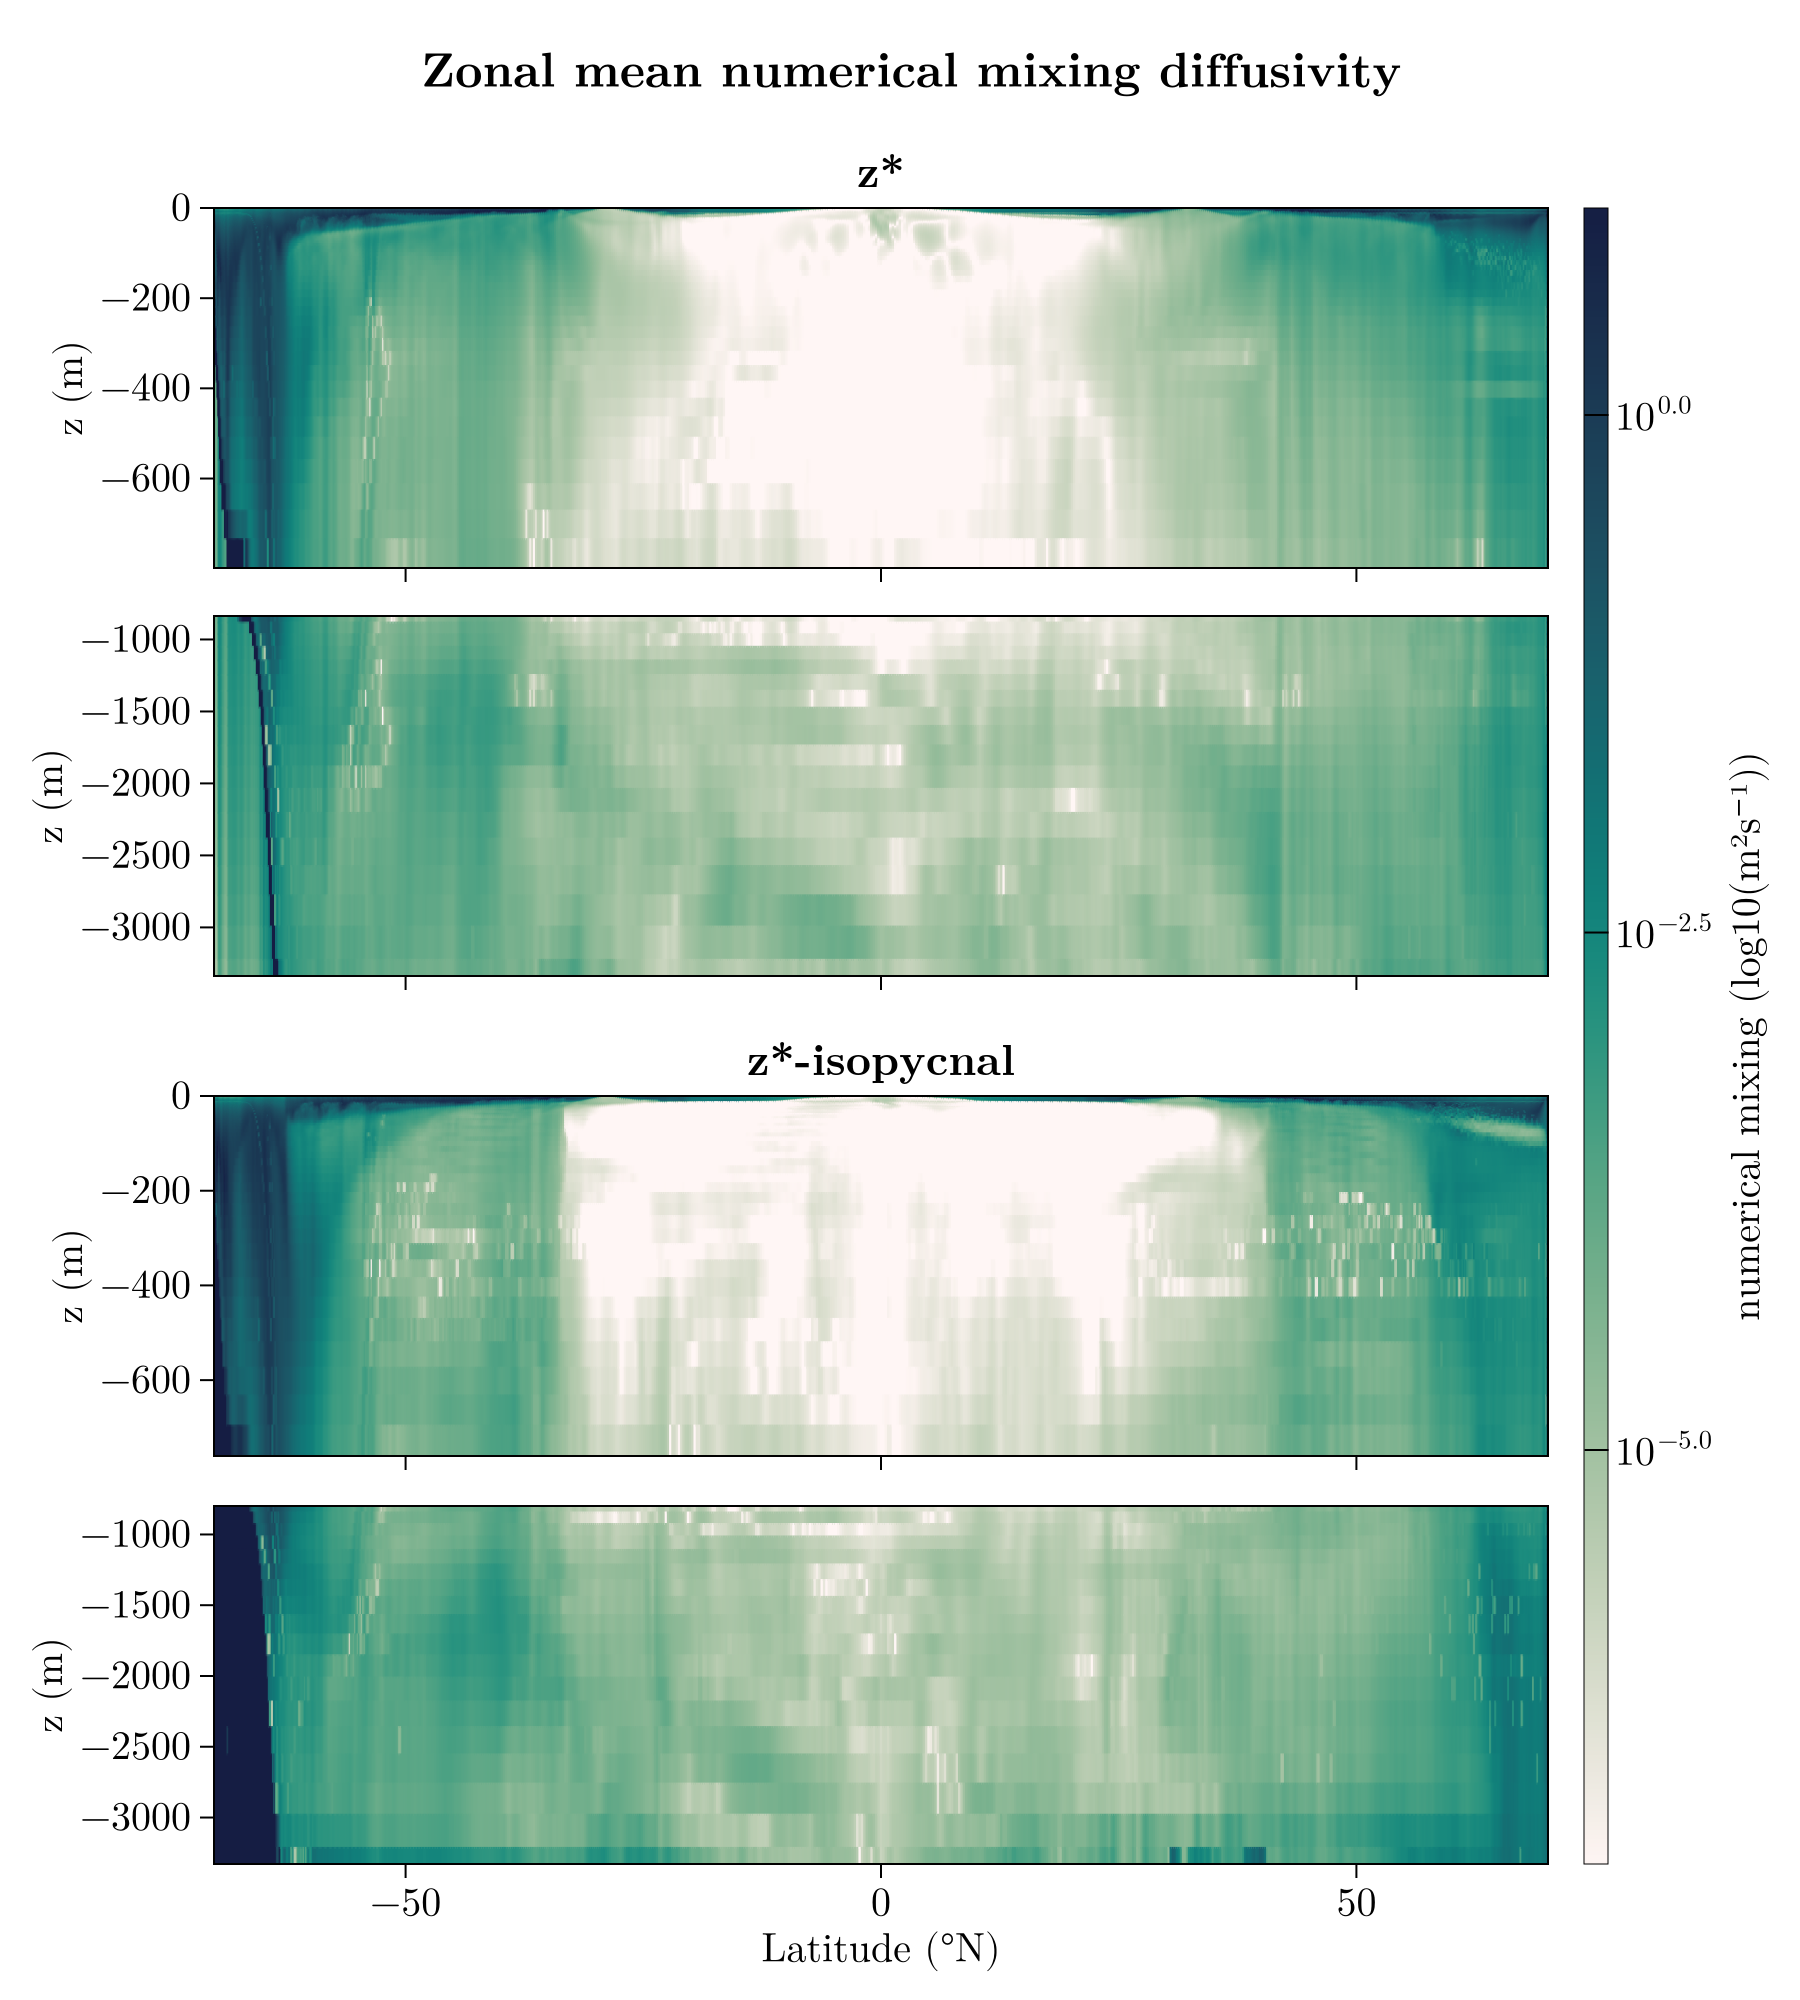

In [52]:
fig = Figure(size = (900, 1000))

colormap = :tempo

top = 1:55
bot = top[end]+1:73
    
colorrange = (1e-7, 1e1)
colorscale = log10

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = title = "z*")
hm = heatmap!(axtop, crs_zstar.lath, crs_zstar.zl[top], nm_zstar_diff[:, top]; colorrange, colorscale, colormap)
axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, crs_zstar.lath, crs_zstar.zl[bot], nm_zstar_diff[:, bot]; colorrange, colorscale, colormap)
ylims!(axbot, crs_zstar.zl[bot[end]], crs_zstar.zl[bot[1]])

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)

axtop = Axis(fig[3, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "z*-isopycnal")
hm = heatmap!(axtop, crs_hycom.lath, crs_hycom.zl[top], nm_hycom_diff[:, top]; colorrange, colorscale, colormap)
axbot = Axis(fig[4, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, crs_hycom.lath, crs_hycom.zl[bot], nm_hycom_diff[:, bot]; colorrange, colorscale, colormap)
ylims!(axbot, crs_hycom.zl[bot[end]], crs_hycom.zl[bot[1]])

hidexdecorations!(axtop, ticks = false)

Colorbar(fig[:, 2], hm, label = "numerical mixing (log10(m²s⁻¹))")

Label(fig[0, :], "Zonal mean numerical mixing diffusivity", fontsize = 24, font = :bold)

fig

In [10]:
save("numerical_diffusivity.png", fig)

## Global numerical mixing

Aiming to get an idea of how numerical mixing is contributing to total mixing that is occuring.